## 💧 Tamburawa Water Treatment Plant (WTP) — Kano, Nigeria
---
### Water Quality Classification: End-to-End Machine Learning Pipeline

---

**Dataset:** Weekly physicochemical monitoring data (2010–2020)  
**Target Variable:** `STATUS` — Water quality classification  
**Objective:** Build, evaluate, and compare ML classifiers to predict water potability status  

---

### 📌 Business Context

> Tamburawa Water Treatment Plant is one of the largest WTPs serving Kano State, Nigeria — a metropolitan area of over 6 million people. Accurate, real-time water quality classification is critical for:
> - **Public health protection** — preventing waterborne disease outbreaks (cholera, typhoid)
> - **Operational efficiency** — guiding treatment dosages and reducing chemical waste
> - **Regulatory compliance** — meeting WHO and Nigerian NAFDAC water quality standards
> - **Early warning systems** — flagging deteriorating water quality before it reaches consumers
>
> A reliable ML model can **automate quality classification**, replacing subjective manual assessment with consistent, data-driven decisions — saving lives and reducing operational costs.

---

### 🗂️ Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Library Imports & Configuration |
| 2 | Data Loading & Initial Inspection |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis (EDA) & Statistical Inference |
| 5 | Data Preprocessing & Feature Engineering |
| 6 | ML Model Development |
| 7 | Model Evaluation & Comparison |
| 8 | Best Model Selection & Business Impact |


---
## Library Imports & Configuration

Import all required libraries upfront following Python best practices.

In [390]:
# Data manipulation 
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Statistical inference 
from scipy import stats

# ML: Preprocessing 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ML: Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ML: Evaluation 
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
    ConfusionMatrixDisplay
)

SEED = 42  # For reproducibility across all stochastic operations
np.random.seed(SEED)

---
## Data Loading & Initial Inspection
Let first understand the raw data's structure — shape, column names, data types, and a preview of values.

In [391]:
# Load the dataset
df_raw = pd.read_excel('Tamburawa_WTP_Kano_Weekly_Dataset.xlsx')
df = df_raw.copy()  # Create a working copy to preserve the original data

# Initial Data Exploration 
print('\nFirst 5 Rows:')
df.head()


First 5 Rows:


,PARAMETERS,pH,TURBIDITY (NTU),CONDUCTIVITY (µs/cm),T.D.S (mg/l),FREE CO2 (mg/l),HARDNESS (mg/l),CALCIUM (mg/l),MAGNESIUM (mg/l),SULPHATE (mg/l),IRON (mg/l),CHLORIDE (mg/l),WQI,STATUS
0,2012-01-04,5.98,0.98,101.4,48.1,10.0,29.18,6.31,0.0,15.0,1.01,30.61,302.23,Unfit
1,2012-01-20,6.31,3.41,90.3,42.9,8.0,20.20,6.31,0.0,0.0,1.02,25.66,306.96,Unfit
2,2012-01-24,6.31,0.48,93.0,44.2,8.0,22.45,8.11,0.0,0.0,0.10,31.58,32.02,Good
3,2012-02-01,7.12,0.71,171.8,82.0,10.0,24.70,7.21,0.0,0.0,0.04,17.77,13.49,Excellent
4,2012-02-08,5.86,0.41,148.9,71.4,8.0,26.93,7.21,0.0,0.0,0.06,36.52,21.10,Excellent


In [392]:
# Initial Data Exploration
df.columns = df.columns.str.strip()  # Remove any leading/trailing whitespace from column names
print('\nData Columns:')
print(df.columns)


Data Columns:
Index(['PARAMETERS', 'pH', 'TURBIDITY (NTU)', 'CONDUCTIVITY (µs/cm)',
       'T.D.S (mg/l)', 'FREE CO2 (mg/l)', 'HARDNESS (mg/l)', 'CALCIUM (mg/l)',
       'MAGNESIUM (mg/l)', 'SULPHATE (mg/l)', 'IRON (mg/l)', 'CHLORIDE (mg/l)',
       'WQI', 'STATUS'],
      dtype='object')


In [393]:
# Shape of the data
print(f'Dataset Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

Dataset Shape : 275 rows × 14 columns


In [394]:
# # Data types and non-null counts
print('Data Types & Non-Null Counts:')
df.info()

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   PARAMETERS            275 non-null    datetime64[ns]
 1   pH                    275 non-null    float64       
 2   TURBIDITY (NTU)       275 non-null    float64       
 3   CONDUCTIVITY (µs/cm)  275 non-null    float64       
 4   T.D.S (mg/l)          275 non-null    float64       
 5   FREE CO2 (mg/l)       275 non-null    float64       
 6   HARDNESS (mg/l)       275 non-null    float64       
 7   CALCIUM (mg/l)        275 non-null    float64       
 8   MAGNESIUM (mg/l)      275 non-null    float64       
 9   SULPHATE (mg/l)       275 non-null    float64       
 10  IRON (mg/l)           275 non-null    float64       
 11  CHLORIDE (mg/l)       275 non-null    float64       
 12  WQI                   275 non-null    float64   

In [395]:
# Target Variable Distribution
print('\nTarget Variable (STATUS) Distribution:')
# Remove whitespace before counting
print(df['STATUS'].str.strip().value_counts())  
print(f'\nClass Balance (%):')
print((df['STATUS'].value_counts(normalize=True) * 100).round(2))


Target Variable (STATUS) Distribution:
STATUS
Excellent    175
Good          62
Poor          26
Very Poor      9
Unfit          3
Name: count, dtype: int64

Class Balance (%):
STATUS
Excellent    63.64
Good         22.55
Poor          9.45
Very Poor     3.27
Unfit         1.09
Name: proportion, dtype: float64


### 📊 Initial Observations

| Observation | Detail |
|-------------|--------|
| Dataset size | 275 weekly observations spanning ~2010–2020 |
| Features | 11 physicochemical parameters + WQI (Water Quality Index) |
| Target classes | 5: Excellent, Good, Poor, Very Poor, Unfit |
| Missing values | **None** dataset is complete |
| Class imbalance | Severe: Excellent ≈63.6%, Unfit ≈1.1% |

> ⚠️ **Class imbalance** is a critical business concern: the minority class (_`Unfit`_) represents the most dangerous water quality state. Models that ignore imbalance will achieve high accuracy by predicting _`Excellent`_ most of the time **but fail to detect hazardous conditions**. We will use stratified splitting and weighted metrics to address this.


---
## Data Cleaning

Real-world sensor and lab data often contain duplicates, trailing whitespace in strings, outlier values from measurement errors, and inconsistent column naming. Cleaning ensures the data entering our models is reliable. Otherwise garbage in garbage out (GIGO).


Rename columns: Standardise to snake_case, remove special characters and trailing spaces. Consistent naming prevents KeyError bugs and improves readability

In [396]:
df.rename(columns={
    'PARAMETERS':         'date',
    'pH':                  'pH',
    'TURBIDITY (NTU)':     'turbidity_NTU',
    'CONDUCTIVITY (µs/cm)':'conductivity_us_cm',
    'T.D.S (mg/l)':        'TDS_mg_l',
    'FREE CO2 (mg/l)':     'free_CO2_mg_l',
    'HARDNESS (mg/l)':     'hardness_mg_l',
    'CALCIUM (mg/l)':      'calcium_mg_l',
    'MAGNESIUM (mg/l)':    'magnesium_mg_l',
    'SULPHATE (mg/l)':     'sulphate_mg_l',
    'IRON (mg/l)':         'iron_mg_l',
    'CHLORIDE (mg/l)':     'chloride_mg_l',
    'WQI':                 'WQI',
    'STATUS':              'status'
}, inplace=True)

print('   New column names:', list(df.columns))

# Ensure correct date type 
# The PARAMETERS column already parsed as datetime; confirm it
df['date'] = pd.to_datetime(df['date'])
print(f'\n: date column confirmed as {df["date"].dtype}✅')

   New column names: ['date', 'pH', 'turbidity_NTU', 'conductivity_us_cm', 'TDS_mg_l', 'free_CO2_mg_l', 'hardness_mg_l', 'calcium_mg_l', 'magnesium_mg_l', 'sulphate_mg_l', 'iron_mg_l', 'chloride_mg_l', 'WQI', 'status']

: date column confirmed as datetime64[ns]✅


In [397]:
# Check for duplicate rows 
n_dupes = df.duplicated().sum()
print(f'\n✅ Duplicate rows found: {n_dupes}')
# No duplicates to drop — each row is a unique weekly sample

# Check for missing values 
null_counts = df.isna().sum()
print(f'\n✅ Missing values per column:')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '   No missing values!')

# Check numeric ranges for physical plausibility 
# WHO drinking water guidelines provide expected ranges
print('\n✅ Numeric range check (min / max):')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for column in numeric_cols:
    print(f'   {column:<25}  min={df[column].min():.3f}   max={df[column    ].max():.3f}')


✅ Duplicate rows found: 0

✅ Missing values per column:
   No missing values!

✅ Numeric range check (min / max):
   pH                         min=5.000   max=8.800
   turbidity_NTU              min=0.000   max=9.000
   conductivity_us_cm         min=8.190   max=722.800
   TDS_mg_l                   min=8.800   max=361.400
   free_CO2_mg_l              min=0.000   max=49.000
   hardness_mg_l              min=17.960   max=62.840
   calcium_mg_l               min=0.000   max=45.000
   magnesium_mg_l             min=0.000   max=28.480
   sulphate_mg_l              min=0.000   max=56.000
   iron_mg_l                  min=0.000   max=1.020
   chloride_mg_l              min=0.000   max=123.000
   WQI                        min=1.420   max=306.960


**Outlier Detection using IQR** 
- Let detect but DO NOT remove outliers automatically. This is because in water quality monitoring, extreme values (e.g., a turbidity spike after heavy rainfall) are REAL and INFORMATIVE, they are exactly the events the model need to learn from. Removing them would create a false clean picture.
- Instead, let document them and let tree-based models handle them naturally.

In [398]:
print('Outlier Count per Feature (IQR method, threshold = 1.5×IQR):')
feature_cols = [c for c in numeric_cols if c != 'WQI']  # WQI is derived, not raw
outlier_summary = {}
for column in feature_cols:
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)).sum()
    outlier_summary[column] = n_out
    print(f'  {column:<25}: {n_out} outliers ({n_out/len(df)*100:.1f}%)')

print('\n⚠️  Decision: Outliers retained — they represent genuine extreme water quality events.')
print(f'   Total rows in cleaned dataset: {df.shape[0]}')

Outlier Count per Feature (IQR method, threshold = 1.5×IQR):
  pH                       : 9 outliers (3.3%)
  turbidity_NTU            : 63 outliers (22.9%)
  conductivity_us_cm       : 13 outliers (4.7%)
  TDS_mg_l                 : 15 outliers (5.5%)
  free_CO2_mg_l            : 9 outliers (3.3%)
  hardness_mg_l            : 36 outliers (13.1%)
  calcium_mg_l             : 37 outliers (13.5%)
  magnesium_mg_l           : 57 outliers (20.7%)
  sulphate_mg_l            : 9 outliers (3.3%)
  iron_mg_l                : 16 outliers (5.8%)
  chloride_mg_l            : 11 outliers (4.0%)

⚠️  Decision: Outliers retained — they represent genuine extreme water quality events.
   Total rows in cleaned dataset: 275


---
## Exploratory Data Analysis (EDA) & Statistical Inference

EDA reveals patterns, distributions, correlations, and anomalies that directly inform modelling decisions. Statistical measures of central tendency (mean, median, mode) tell us about typical water quality; measures of spread (std, IQR) tell us about variability. These insights have direct operational and business implications.


Descriptive Statistics (Measures of Central Tendency & Dispersion) 
 - Mean = arithmetic average; sensitive to outliers
 - Median = middle value; robust to outliers — better for skewed distributions
 - Std = standard deviation; measure of variability
 - Skewness > 0 → right-skewed (long right tail); < 0 → left-skewed
 - Kurtosis > 3 → heavier tails than normal distribution

In [399]:
desc = df[feature_cols + ['WQI']].describe().T
desc['median']   = df[feature_cols + ['WQI']].median()
desc['mode']     = df[feature_cols + ['WQI']].mode().iloc[0]
desc['skewness'] = df[feature_cols + ['WQI']].skew()
desc['kurtosis'] = df[feature_cols + ['WQI']].kurt()
desc['cv_%']     = (desc['std'] / desc['mean'] * 100).round(2)  # Coefficient of Variation

display_cols = ['mean', 'median', 'mode', 'std', 'min', 'max', 'skewness', 'kurtosis', 'cv_%']
print('Comprehensive Descriptive Statistics:')
print(desc[display_cols].round(3).to_string())

Comprehensive Descriptive Statistics:
                       mean  median   mode     std    min     max  skewness  kurtosis    cv_%
pH                    6.627    6.60   7.00   0.634   5.00    8.80     0.668     1.237    9.56
turbidity_NTU         1.359    0.94   1.00   1.348   0.00    9.00     3.019    11.273   99.18
conductivity_us_cm  130.093  110.00  64.00  80.308   8.19  722.80     3.638    19.597   61.73
TDS_mg_l             65.035   55.10  50.00  40.153   8.80  361.40     3.672    19.679   61.74
free_CO2_mg_l         9.851    8.00   8.00   5.506   0.00   49.00     3.116    18.158   55.89
hardness_mg_l        30.479   26.93  26.93   7.301  17.96   62.84     2.034     5.022   23.96
calcium_mg_l          9.883    7.21   7.21   6.869   0.00   45.00     3.507    12.682   69.51
magnesium_mg_l        3.498    2.19   2.19   4.117   0.00   28.48     3.429    13.193  117.71
sulphate_mg_l        17.426   16.00   0.00  13.158   0.00   56.00     0.490    -0.110   75.50
iron_mg_l             

### 📊 Statistical Inference — Key Findings

| Parameter | Key Insight | Business Implication |
|-----------|-------------|----------------------|
| **pH** (mean=6.63) | Below WHO ideal of 7.0–8.5; slightly acidic | Acidic water is corrosive to pipes; increases risk of heavy metal leaching |
| **Turbidity** (median=0.94 NTU) | Most samples near WHO limit (1 NTU) but max=9 NTU | High turbidity indicates suspended solids; affects disinfection efficacy |
| **Conductivity** (CV=61.7%) | Very high variability; outliers up to 722 µs/cm | High conductivity weeks signal pollution events or dry-season concentration |
| **TDS** (skew=2.96) | Strongly right-skewed; most weeks low, occasional spikes | High TDS events need urgent operational response |
| **Iron** (skew=4.96) | Most extreme skewness; mostly near-zero with rare spikes | Iron spike events directly cause Unfit/Very Poor classification |
| **WQI** (median=20.9) | Median well below 25 (Excellent threshold) | Majority of supply is of high quality — reassuring for public health |
| **Magnesium** (mode=2.19) | Bimodal-like distribution | Low hardness levels; possible health benefits for cardiovascular health |


# Target Variable Distribution: 
- understanding class balance is essential before modelling.
- Severe imbalance biases accuracy metrics and classifier training.

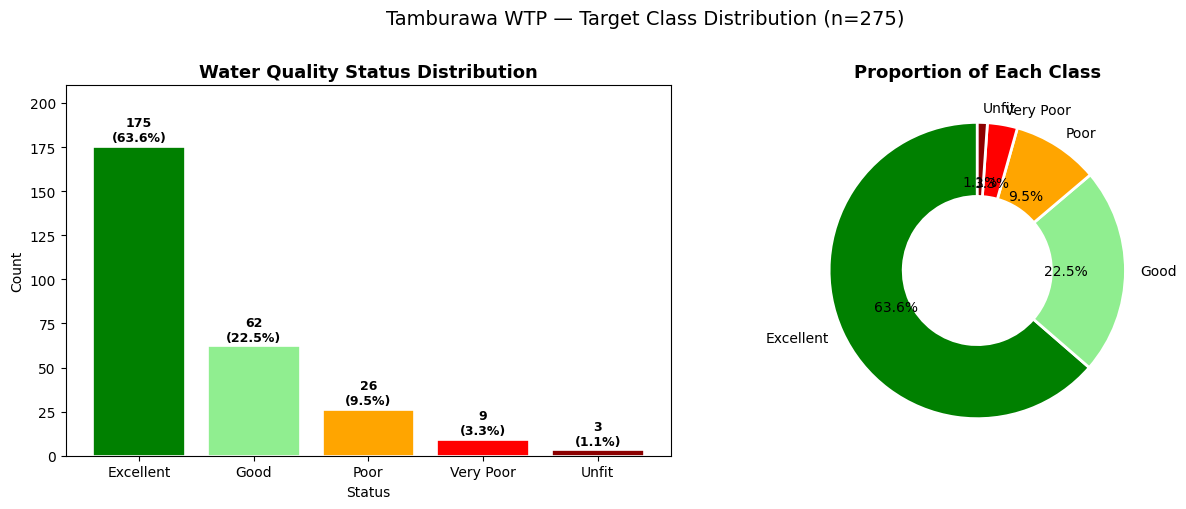

In [400]:
status_order = ['Excellent', 'Good', 'Poor', 'Very Poor', 'Unfit']
status_colors = ['green', 'lightgreen', 'orange', 'red', 'darkred']
counts = df['status'].value_counts().reindex(status_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(status_order, counts.values, color=status_colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Water Quality Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.2)

# Donut chart
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
axes[1].pie(counts.values, labels=status_order, colors=status_colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=wedge_props,
            textprops={'fontsize': 10})
axes[1].set_title('Proportion of Each Class', fontsize=13, fontweight='bold')

plt.suptitle('Tamburawa WTP — Target Class Distribution (n=275)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

**Time-Series Trends**
- Monitoring trends over time reveals seasonal patterns and long-term shifts.
- This informs WHEN the treatment plant needs extra intervention capacity.

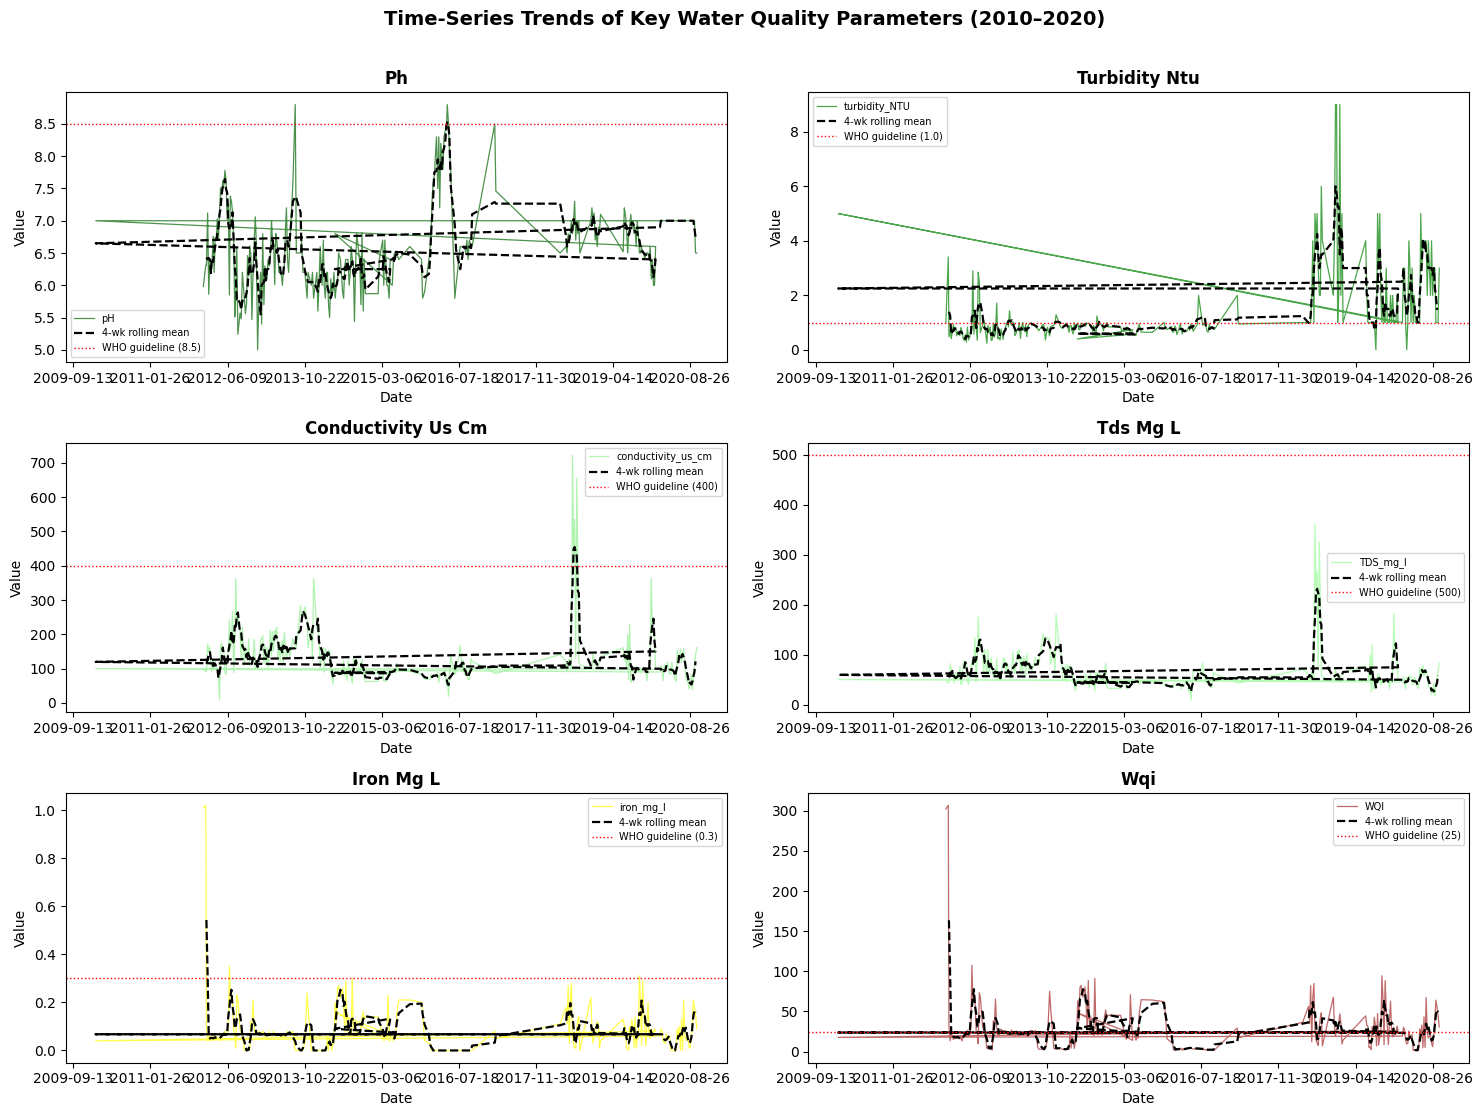

In [401]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes = axes.flatten()

time_features = ['pH', 'turbidity_NTU', 'conductivity_us_cm', 'TDS_mg_l', 'iron_mg_l', 'WQI']
time_colors   = ['darkgreen', 'green','lightgreen', 'palegreen', 'yellow', 'brown']

# WHO/NAFDAC guideline reference lines for key parameters
who_limits = {'pH': 8.5, 'turbidity_NTU': 1.0, 'conductivity_us_cm': 400,
              'TDS_mg_l': 500, 'iron_mg_l': 0.3, 'WQI': 25}

for ax, feat, col in zip(axes, time_features, time_colors):
    ax.plot(df['date'], df[feat], color=col, alpha=0.7, linewidth=0.9, label=feat)
    # Rolling 4-week average to show trend
    rolling_mean = df[feat].rolling(window=4, center=True).mean()
    ax.plot(df['date'], rolling_mean, color='black', linewidth=1.6,
            linestyle='--', label='4-wk rolling mean')
    if feat in who_limits:
        ax.axhline(who_limits[feat], color='red', linewidth=1.0,
                   linestyle=':', label=f'WHO guideline ({who_limits[feat]})')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Value')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_locator(ticker.AutoLocator())

plt.suptitle('Time-Series Trends of Key Water Quality Parameters (2010–2020)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_time_series.png', bbox_inches='tight', dpi=120)
plt.show()

Feature Distributions (Histograms + KDE): Histograms reveal whether features are normally distributed or skewed.
 - Many ML algorithms (e.g. Logistic Regression, SVM) assume near-normality.
 - Heavily skewed features may require transformation at preprocessing stage.

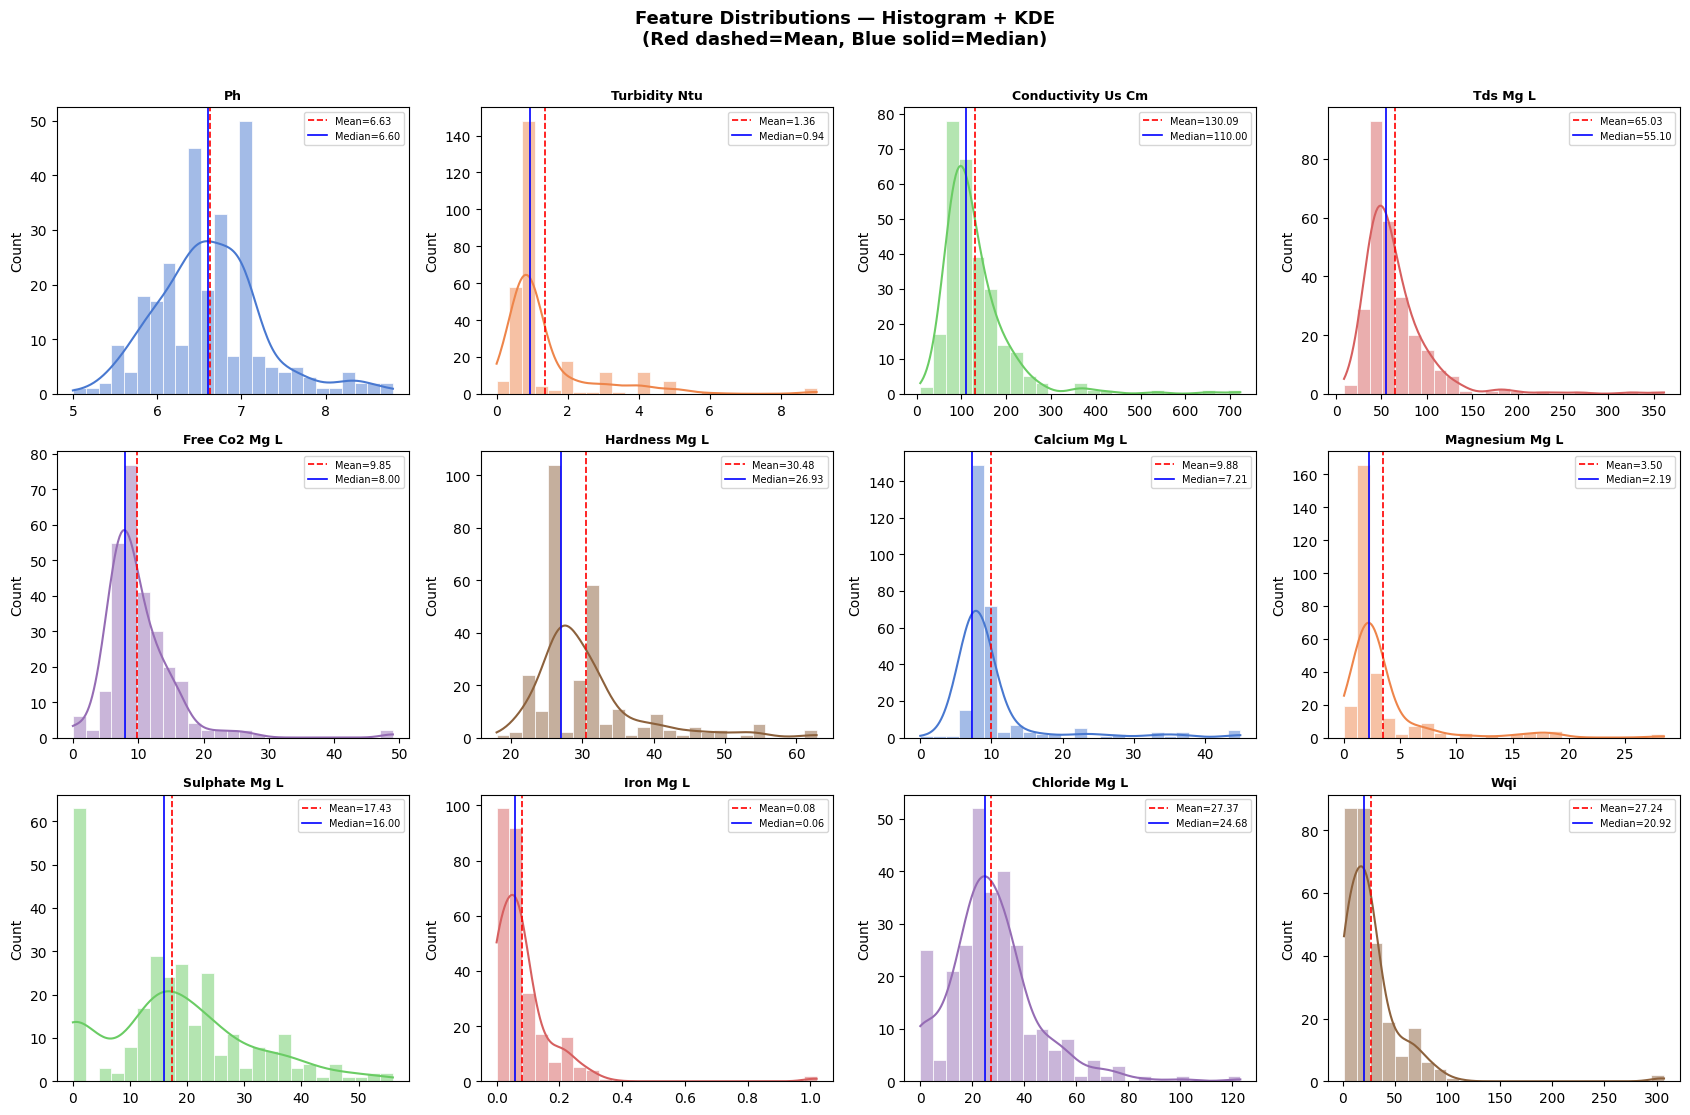

In [402]:
all_features = feature_cols + ['WQI']
fig, axes = plt.subplots(3, 4, figsize=(17, 11))
axes = axes.flatten()

for i, (col, ax) in enumerate(zip(all_features, axes)):
    sns.histplot(df[col], ax=ax, kde=True, color=sns.color_palette('muted')[i % 6],
                 bins=25, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='blue',   linestyle='-',  linewidth=1.2, label=f'Median={df[col].median():.2f}')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Hide unused subplot
for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Histogram + KDE\n(Red dashed=Mean, Blue solid=Median)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

Box Plots by Status 
 - Box plots stratified by STATUS show how each parameter differs across classes.
 - Features with large between-class differences will be powerful predictors.
 - This directly informs feature importance expectations.

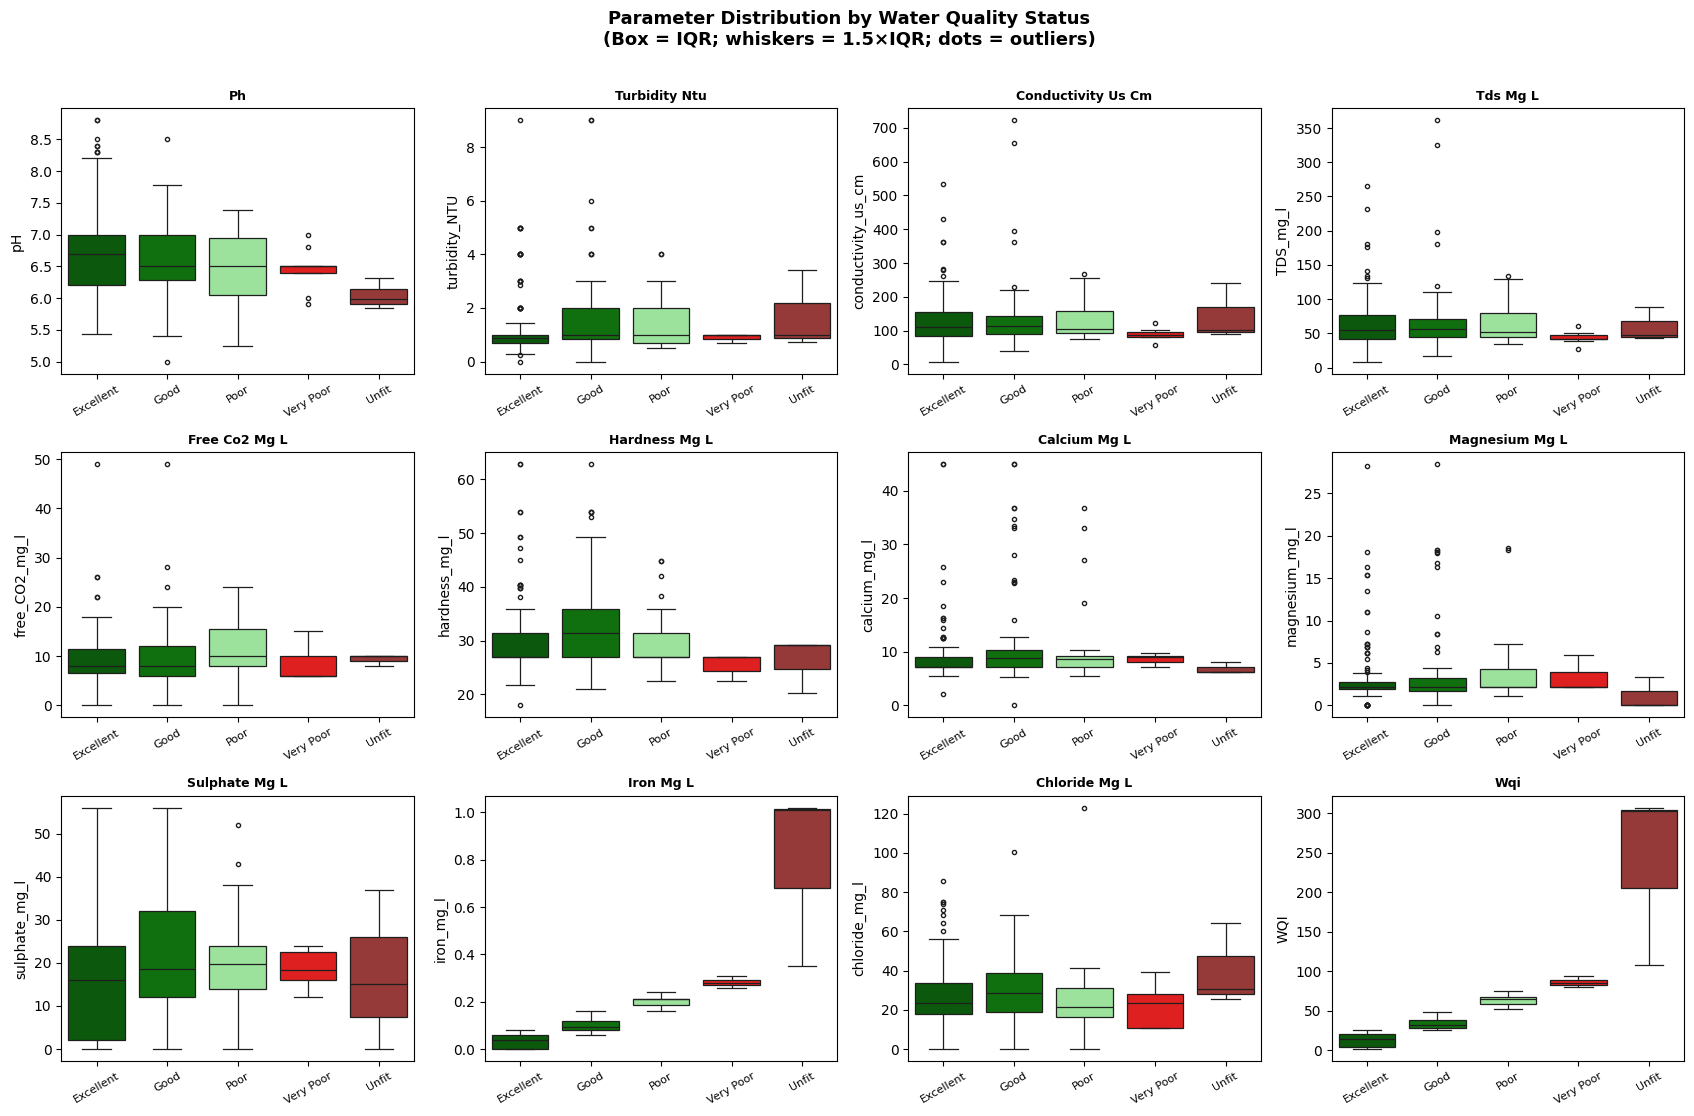

In [403]:
fig, axes = plt.subplots(3, 4, figsize=(17, 11))
axes = axes.flatten()
palette = {'Excellent': 'darkgreen', 'Good': 'green', 'Poor': 'lightgreen',
           'Very Poor': 'red', 'Unfit': 'brown'}

for i, (col, ax) in enumerate(zip(all_features, axes)):
    sns.boxplot(data=df, x='status', y=col, ax=ax, order=status_order,
                palette=palette, linewidth=0.9, fliersize=3)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Parameter Distribution by Water Quality Status\n(Box = IQR; whiskers = 1.5×IQR; dots = outliers)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_boxplots_by_status.png', bbox_inches='tight', dpi=120)
plt.show()

Correlation Matrix 
 - Pearson correlation identifies linear relationships between features.
 - Highly correlated features (|r| > 0.90) are candidates for removal to reduce multicollinearity and this affect Logistic Regression and SVM performance.
 - Tree-based models are naturally immune to multicollinearity.

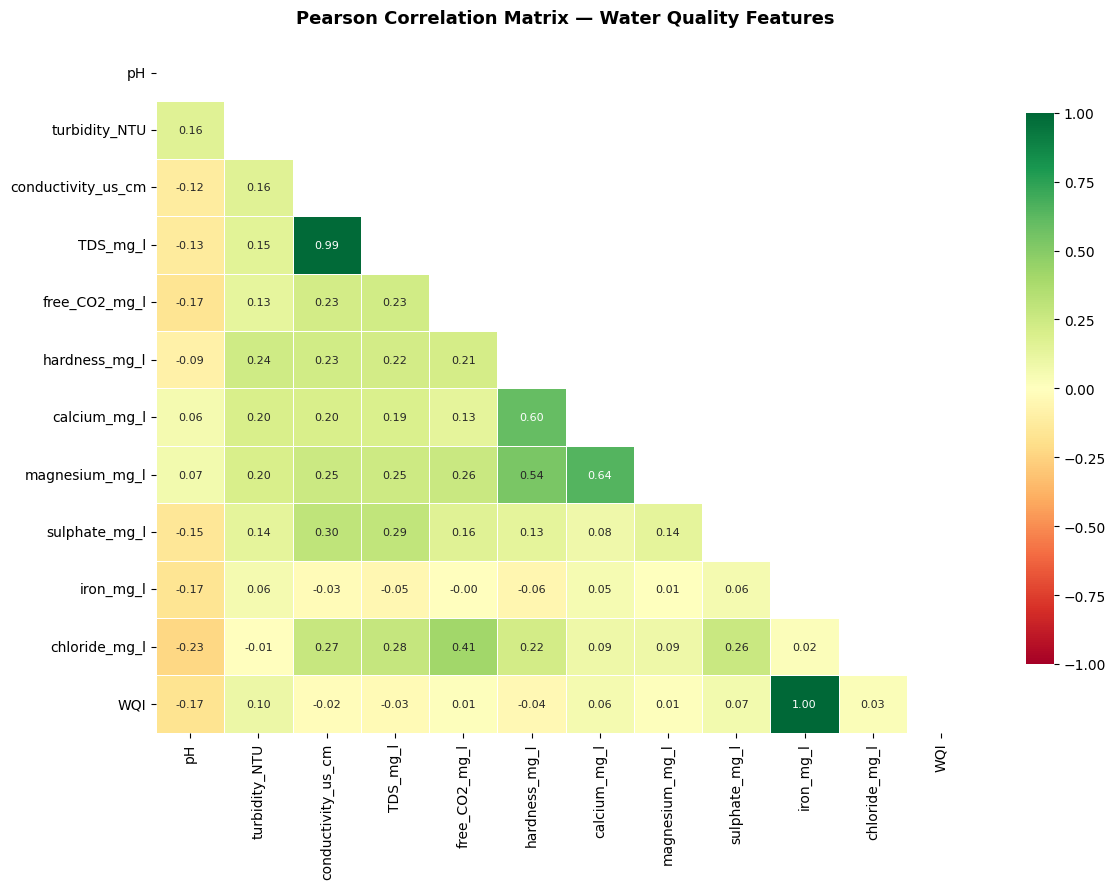

Highly Correlated Feature Pairs (|r| > 0.90):
  TDS_mg_l                   conductivity_us_cm         r=0.987
  WQI                        iron_mg_l                  r=0.999


In [404]:
corr_matrix = df[all_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix — Water Quality Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_05_correlation_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

# Flag highly correlated pairs
print('Highly Correlated Feature Pairs (|r| > 0.90):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.90:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))
            print(f'  {corr_matrix.columns[i]:25}  {corr_matrix.columns[j]:25}  r={r:.3f}')
if not high_corr:
    print('  None found — no multicollinearity concern at 0.90 threshold.')

Violin Plots (WQI & Key Parameters by Status)
 - Violin plots combine box plots with KDE, showing the full distribution shape.
 - They are particularly useful for revealing multimodal distributions within classes.

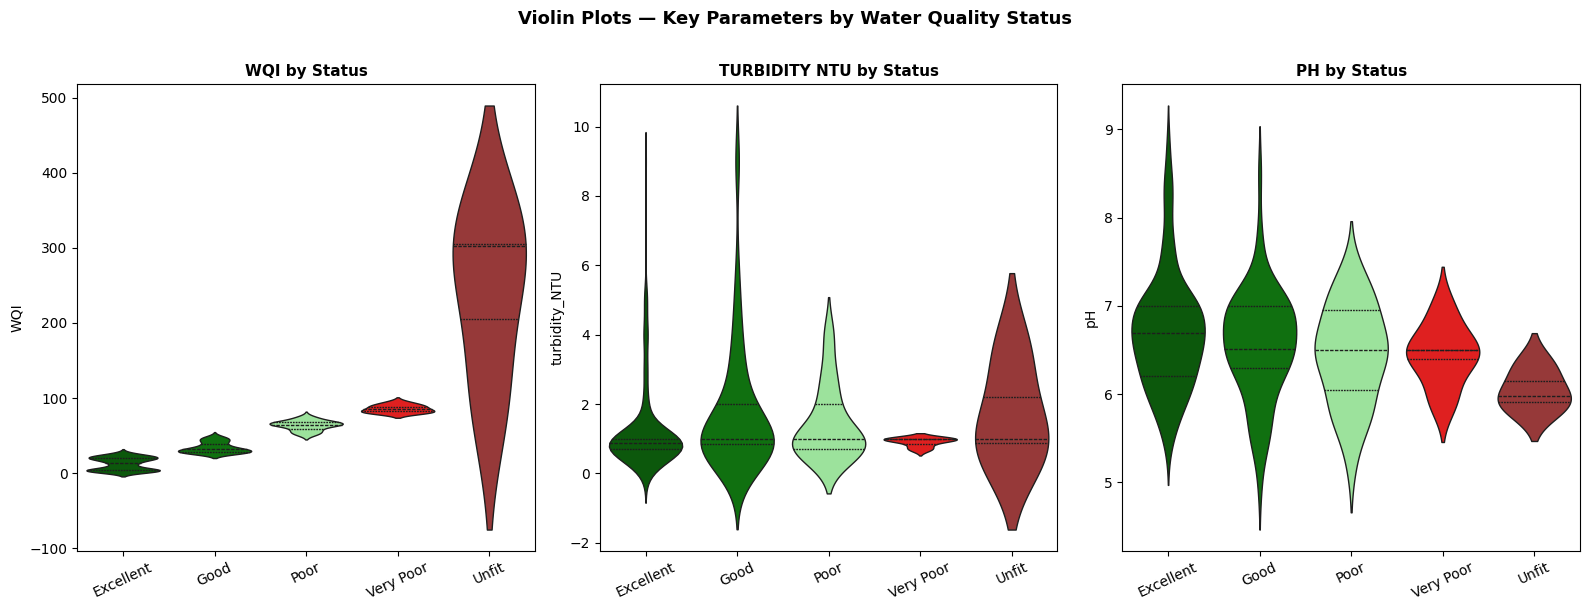

In [405]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
key_params = ['WQI', 'turbidity_NTU', 'pH']

for ax, param in zip(axes, key_params):
    sns.violinplot(data=df, x='status', y=param, order=status_order,
                   palette=palette, ax=ax, inner='quartile', linewidth=1.0)
    ax.set_title(f'{param.replace("_", " ").upper()} by Status',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=25)

plt.suptitle('Violin Plots — Key Parameters by Water Quality Status',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_violin_plots.png', bbox_inches='tight', dpi=120)
plt.show()

Pair Plot (Key Features) 
 - Pair plots reveal bivariate relationships and class separability.
 - If classes are well-separated in 2D feature space, even simple models may work.
 - We use the 4 most diagnostically important parameters for readability.


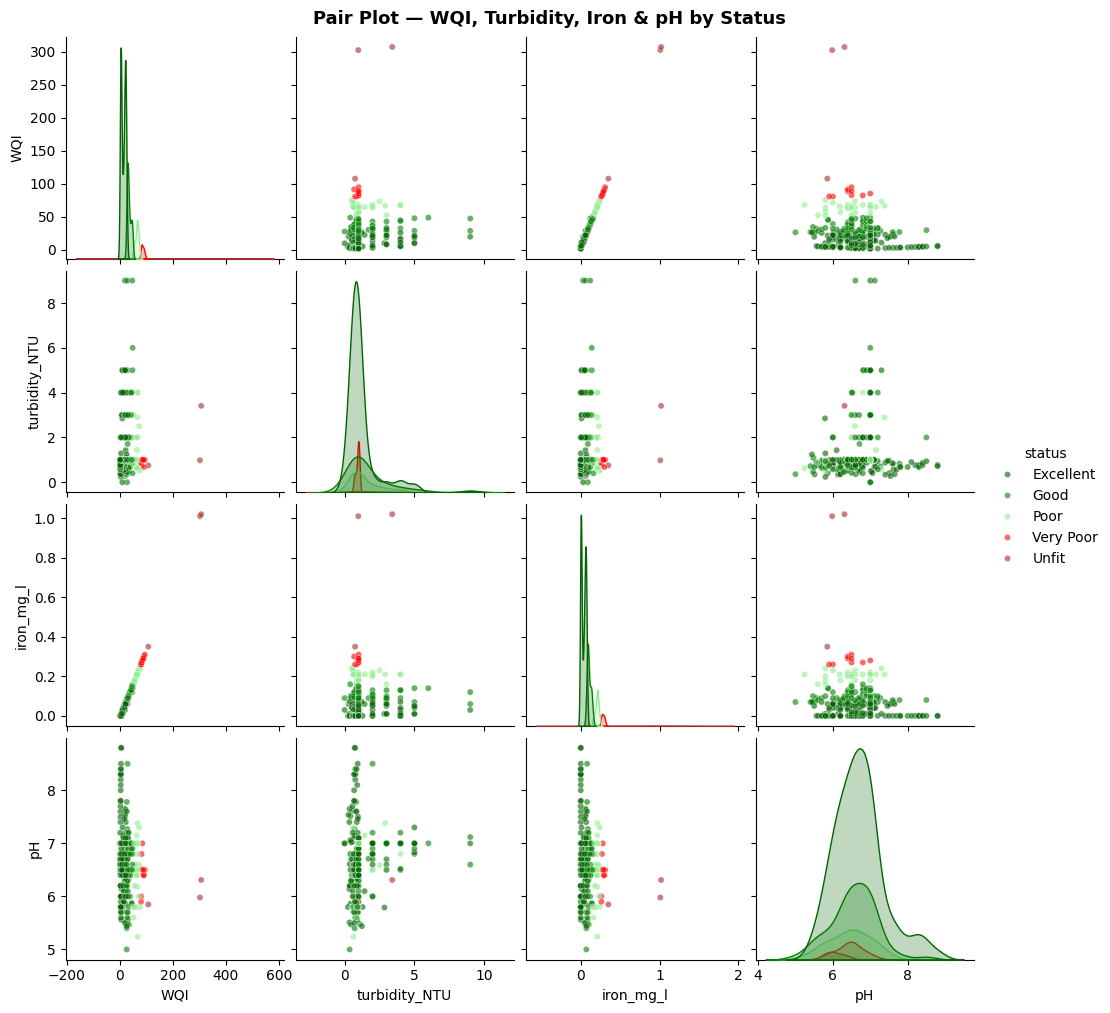

In [406]:
pair_features = ['WQI', 'turbidity_NTU', 'iron_mg_l', 'pH', 'status']
g = sns.pairplot(df[pair_features], hue='status', hue_order=status_order,
                 palette=palette, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20},
                 height=2.5)
g.figure.suptitle('Pair Plot — WQI, Turbidity, Iron & pH by Status',
                   fontsize=13, fontweight='bold', y=1.01)
plt.savefig('fig_07_pairplot.png', bbox_inches='tight', dpi=110)
plt.show()

Statistical Testing (One-Way ANOVA) 
 - ANOVA tests whether the means of a feature differ significantly across status classes.
 - H₀: All group means are equal (feature is not predictive of status)
 - H₁: At least one group mean differs (feature is predictive)
 - p < 0.05 → reject H₀ → feature has statistically significant discriminative power
 - F-statistic: ratio of between-group variance to within-group variance (higher = better)

In [407]:
print('One-Way ANOVA Results — Feature vs. STATUS')
print(f'{"Feature":<25} {"F-statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 66)

groups_by_status = {s: df[df['status'] == s] for s in status_order}

for feat in all_features:
    groups = [groups_by_status[s][feat].values for s in status_order]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '✅ Yes' if p_val < 0.05 else '❌ No'
    print(f'{feat:<25} {f_stat:>12.3f} {p_val:>12.4e} {sig:>14}')

One-Way ANOVA Results — Feature vs. STATUS
Feature                    F-statistic      p-value   Significant?
------------------------------------------------------------------
pH                               2.162   7.3543e-02           ❌ No
turbidity_NTU                    2.371   5.2828e-02           ❌ No
conductivity_us_cm               1.168   3.2540e-01           ❌ No
TDS_mg_l                         1.129   3.4316e-01           ❌ No
free_CO2_mg_l                    0.972   4.2330e-01           ❌ No
hardness_mg_l                    3.694   6.0193e-03          ✅ Yes
calcium_mg_l                     4.545   1.4387e-03          ✅ Yes
magnesium_mg_l                   2.319   5.7355e-02           ❌ No
sulphate_mg_l                    1.383   2.4002e-01           ❌ No
iron_mg_l                      374.526  7.6331e-109          ✅ Yes
chloride_mg_l                    1.214   3.0516e-01           ❌ No
WQI                            382.050  7.8409e-110          ✅ Yes


Seasonal / Monthly Analysis 
 - In Kano, the rainy season (Jun–Sep) increases turbidity due to surface runoff.
 - Dry season (Nov–Mar) may increase TDS due to water concentration.
 - Understanding seasonality informs when to increase treatment intensity.

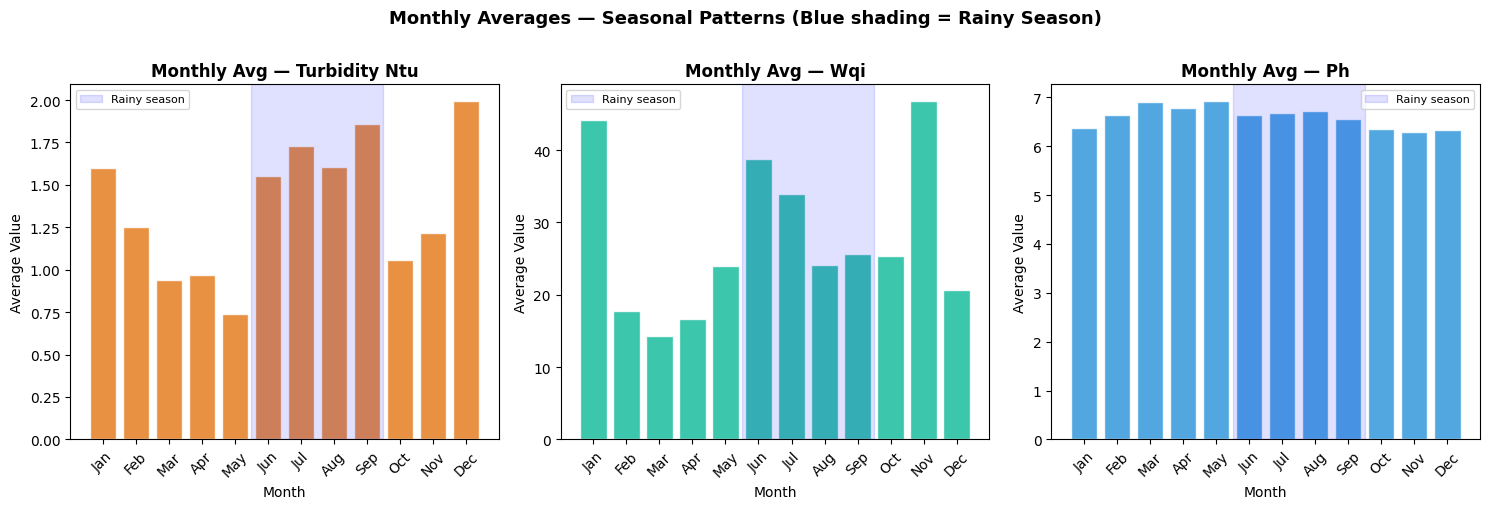

In [408]:
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = df.groupby('month')[['turbidity_NTU', 'WQI', 'pH']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
params_colors = ['#e67e22', '#1abc9c', '#3498db']
for ax, col, color in zip(axes, ['turbidity_NTU', 'WQI', 'pH'], params_colors):
    ax.bar(range(1, 13), monthly_avg[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.set_title(f'Monthly Avg — {col.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('Average Value')
    # Shade rainy season
    ax.axvspan(5.5, 9.5, alpha=0.12, color='blue', label='Rainy season')
    ax.legend(fontsize=8)

plt.suptitle('Monthly Averages — Seasonal Patterns (Blue shading = Rainy Season)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_08_seasonal_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Data Preprocessing & Feature Engineering

**Why this step?**  
ML algorithms cannot process raw text labels or unscaled numeric features. We must:
1. **Encode** the target variable (STATUS → from string to integers)
2. **Scale** features so distance-based and gradient algorithms aren't dominated by large-magnitude features
3. **Split** data into train/test sets using stratification to preserve class proportions
4. Add a **temporal feature** to capture seasonal patterns


Feature Engineering (Temporal Features)
 - Adding month and year as features captures seasonality.
 - The raw date column cannot be used directly by most algorithms.

In [409]:
df['month_num'] = df['date'].dt.month   # 1–12 seasonal signal
df['year_num']  = df['date'].dt.year    # Long-term trend signal

LabelEncoder — Target Variable 
 - LabelEncoder maps string class labels to integers [0, n_classes-1].
 - The mapping will be alphabetical order by default.

In [410]:
le = LabelEncoder()
df['status_encoded'] = le.fit_transform(df['status'])

print('\n✅LabelEncoder applied to STATUS column.')
print('   Encoding map (class → integer):')
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
for k, v in sorted(label_map.items(), key=lambda x: x[1]):
    count = (df['status'] == k).sum()
    print(f'   {v} → {k:<12}  (n={count})')


✅LabelEncoder applied to STATUS column.
   Encoding map (class → integer):
   0 → Excellent     (n=175)
   1 → Good          (n=62)
   2 → Poor          (n=26)
   3 → Unfit         (n=3)
   4 → Very Poor     (n=9)


Define Feature Matrix (X) and Target Vector (y) 
 - All physicochemical features plus WQI and temporal features were included.
 - The date column is excluded (not numeric); status and status_encoded excluded (target).

In [411]:
FEATURE_COLS = [
    'pH', 'turbidity_NTU', 'conductivity_us_cm', 'TDS_mg_l',
    'free_CO2_mg_l', 'hardness_mg_l', 'calcium_mg_l', 'magnesium_mg_l',
    'sulphate_mg_l', 'iron_mg_l', 'chloride_mg_l', 'WQI',
    'month_num', 'year_num'
]

X = df[FEATURE_COLS]
y = df['status_encoded']

print(f'✅ Feature matrix X shape: {X.shape}')
print(f'   Target vector y shape: {y.shape}')
print(f'   Features used: {FEATURE_COLS}')

✅ Feature matrix X shape: (275, 14)
   Target vector y shape: (275,)
   Features used: ['pH', 'turbidity_NTU', 'conductivity_us_cm', 'TDS_mg_l', 'free_CO2_mg_l', 'hardness_mg_l', 'calcium_mg_l', 'magnesium_mg_l', 'sulphate_mg_l', 'iron_mg_l', 'chloride_mg_l', 'WQI', 'month_num', 'year_num']


Train/Test Split (Stratified) 
 - Stratified split preserves the original class proportions in both subsets.
 - This is critical for imbalanced datasets, without it, minority classes
 (Unfit, Very Poor) might be entirely absent from the test set.
 - 80/20 split balances having enough training data vs. a meaningful test set.

In [412]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
train_dist = pd.Series(y_train).map({v: k for k, v in label_map.items()}).value_counts()
print(train_dist.to_string())
print(f'\n   Class distribution in test set:')
test_dist = pd.Series(y_test).map({v: k for k, v in label_map.items()}).value_counts()
print(test_dist.to_string())

status_encoded
Excellent    140
Good          50
Poor          21
Very Poor      7
Unfit          2

   Class distribution in test set:
status_encoded
Excellent    35
Good         12
Poor          5
Very Poor     2
Unfit         1


**Feature Scaling (StandardScaler)**: transforms features to mean=0, std=1.
 - CRITICAL: Fit ONLY on training data; transform both train and test.
 - Fitting on test data would cause data leakage — artificially inflating performance.
 - Required by: Logistic Regression, SVM, KNN (distance-based)
 - Not needed by: Decision Trees, Random Forest, Gradient Boosting (scale-invariant)
 - We scale once and use for all models for consistency.

In [413]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform on training only
X_test_scaled  = scaler.transform(X_test)        # Transform test using training stats

print('✅ StandardScaler applied.')
print(f'   Training set mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0).round(4)}')
print(f'   Training set std  (first 5 features): {X_train_scaled[:, :5].std(axis=0).round(4)}')
print('   → Means ≈ 0, Stds ≈ 1 ✓')

# Summary of preprocessing
print('\n' + '='*55)
print('PREPROCESSING SUMMARY')
print('='*55)
print(f'  Total samples        : {len(df)}')
print(f'  Training samples     : {len(X_train)}')
print(f'  Test samples         : {len(X_test)}')
print(f'  Number of features   : {len(FEATURE_COLS)}')
print(f'  Target classes       : {len(le.classes_)} ({list(le.classes_)})')
print(f'  Scaling method       : StandardScaler (mean=0, std=1)')
print(f'  Encoding method      : LabelEncoder')
print(f'  Data leakage guard   : scaler fit on train only ✓')
print('='*55)

✅ StandardScaler applied.
   Training set mean (first 5 features): [ 0.  0.  0. -0. -0.]
   Training set std  (first 5 features): [1. 1. 1. 1. 1.]
   → Means ≈ 0, Stds ≈ 1 ✓

PREPROCESSING SUMMARY
  Total samples        : 275
  Training samples     : 220
  Test samples         : 55
  Number of features   : 14
  Target classes       : 5 (['Excellent', 'Good', 'Poor', 'Unfit', 'Very Poor'])
  Scaling method       : StandardScaler (mean=0, std=1)
  Encoding method      : LabelEncoder
  Data leakage guard   : scaler fit on train only ✓


---
## Machine Learning Model Development

**Why these models?**  
We train 7 classifiers representing diverse algorithmic families:

| Model | Family | Strengths | Weaknesses |
|-------|--------|-----------|------------|
| Logistic Regression | Linear | Interpretable, fast | Assumes linearity |
| Decision Tree | Tree | Interpretable, handles non-linearity | Prone to overfitting |
| Random Forest | Ensemble (Bagging) | Robust, handles imbalance | Slower, less interpretable |
| Gradient Boosting | Ensemble (Boosting) | High accuracy, handles imbalance | Slow to train, many hyperparameters |
| SVM | Kernel method | Effective in high dimensions | Sensitive to scaling, slow for large data |
| KNN | Instance-based | Simple, non-parametric | Slow at inference, sensitive to scale |
| Naive Bayes | Probabilistic | Very fast, works with small data | Strong independence assumption |

Training multiple models and comparing them guards against cherry-picking and reveals the algorithm that best matches our data's underlying patterns.


Define models with their configurations
 - class_weight='balanced' adjusts weights inversely proportional to class frequencies
 - This is crucial for our imbalanced dataset — it penalises misclassification of minority classes (Unfit, Very Poor) more heavily during training.
 - Models pipelined with scaled data where required (Logistic Regression, SVM, KNN).

In [414]:
import time
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced', C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=SEED, class_weight='balanced', max_depth=10, min_samples_leaf=2
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=SEED, class_weight='balanced',
        n_jobs=-1, max_depth=None
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=SEED, learning_rate=0.1, max_depth=4
    ),
    'SVM': SVC(
        kernel='rbf', random_state=SEED, class_weight='balanced',
        probability=True, C=10, gamma='scale'
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='distance', n_jobs=-1
    ),
    'Naive Bayes': GaussianNB()
}

Train all models and collect results 
 - The SCALED data was used for all models for consistency.
 - StratifiedKFold cross-validation (5 folds) gives a more reliable performance estimate than a single train/test split, especially with small datasets.

In [415]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'{"Model":<22} {"Train Acc":>10} {"Test Acc":>10} {"CV Mean":>9} {"CV Std":>8} {"F1-Macro":>10} {"Time(s)":>9}')
print('-' * 82)

for name, model in models.items():
    start = time.time()

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    # Determine the metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred_test)
    f1_macro  = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

    # Cross-validation (5-fold stratified)
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=cv, scoring='accuracy', n_jobs=-1)
    elapsed = time.time() - start

    results[name] = {
        'model': model,
        'train_acc': train_acc, 'test_acc': test_acc,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'f1_macro': f1_macro,
        'y_pred': y_pred_test,
        'time_seconds': elapsed
    }

    print(f'{name:<22} {train_acc:>10.4f} {test_acc:>10.4f} '
          f'{cv_scores.mean():>9.4f} {cv_scores.std():>8.4f} '
          f'{f1_macro:>10.4f} {elapsed:>9.2f}')

Model                   Train Acc   Test Acc   CV Mean   CV Std   F1-Macro   Time(s)
----------------------------------------------------------------------------------
Logistic Regression        0.9182     0.8727    0.8500   0.0668     0.8767      0.42
Decision Tree              1.0000     1.0000    0.9909   0.0111     1.0000      0.10
Random Forest              1.0000     1.0000    0.9682   0.0232     1.0000      5.66
Gradient Boosting          1.0000     1.0000    0.9955   0.0091     1.0000     12.53
SVM                        0.9864     0.8364    0.8455   0.0265     0.8896      0.28
KNN                        1.0000     0.8000    0.7227   0.0364     0.8004      0.17
Naive Bayes                0.8909     0.8727    0.8545   0.0396     0.8630      0.07


---
## Model Evaluation & Performance Comparison

**Why multiple metrics?**  
- **Accuracy** alone is misleading for imbalanced classes (a model predicting `Excellent` always gets >63% accuracy)
- **F1-Macro** averages F1 across all classes equally — penalises poor performance on minority classes
- **Precision** = of predicted positives, how many are correct
- **Recall** = of actual positives, how many did we catch (critical for detecting `Unfit` water)
- **Confusion Matrix** shows exactly where misclassifications occur
- **Cross-Validation** checks that performance is stable and not just lucky on one split


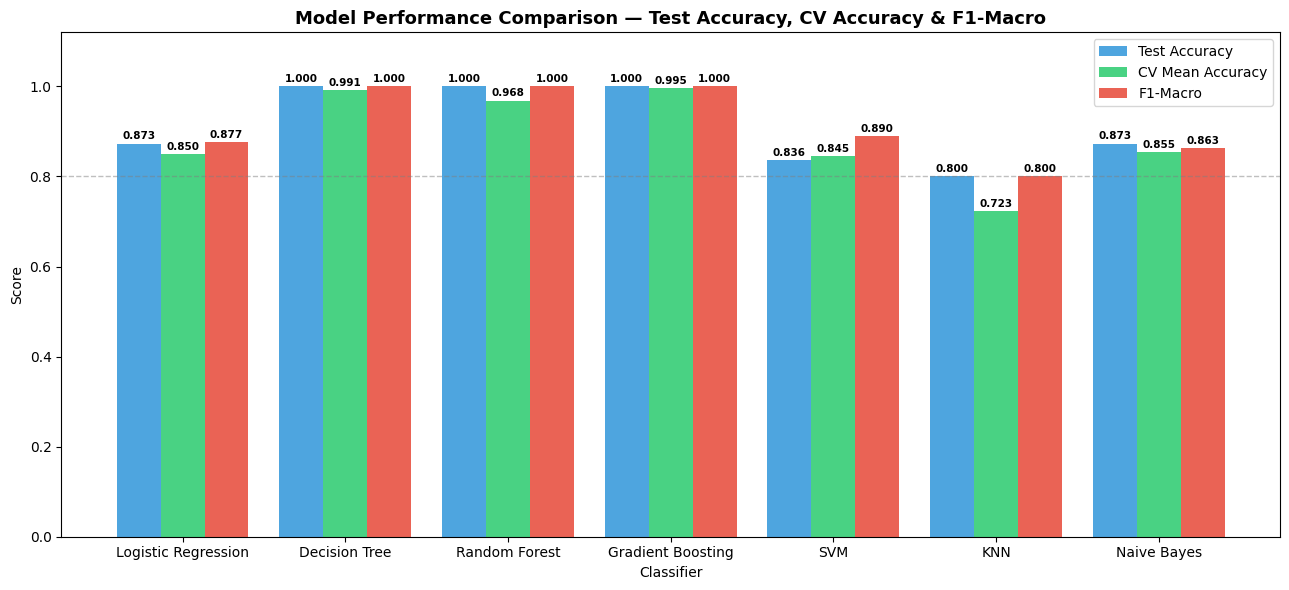

In [416]:
# Performance Comparison Bar Chart 

model_names = list(results.keys())
test_accs   = [results[m]['test_acc']  for m in model_names]
cv_means    = [results[m]['cv_mean']   for m in model_names]
f1_macros   = [results[m]['f1_macro']  for m in model_names]

x = np.arange(len(model_names))
width = 0.27

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width, test_accs, width, label='Test Accuracy',   color='#3498db', alpha=0.87)
bars2 = ax.bar(x,         cv_means,  width, label='CV Mean Accuracy', color='#2ecc71', alpha=0.87)
bars3 = ax.bar(x + width, f1_macros, width, label='F1-Macro',         color='#e74c3c', alpha=0.87)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Classifier')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Accuracy, CV Accuracy & F1-Macro',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names,  ha='center')
ax.set_ylim(0, 1.12)
ax.legend()
ax.axhline(0.8, linestyle='--', color='grey', alpha=0.5, linewidth=1.0, label='0.80 reference')

plt.tight_layout()
plt.savefig('fig_09_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

**Confusion Matrices** All Models: Confusion matrices reveal misclassification patterns. For water quality, the most dangerous error is:
_FALSE NEGATIVE_ for 'Unfit' — predicting Unfit water as Good/Excellent, this would allow hazardous water to reach consumers.

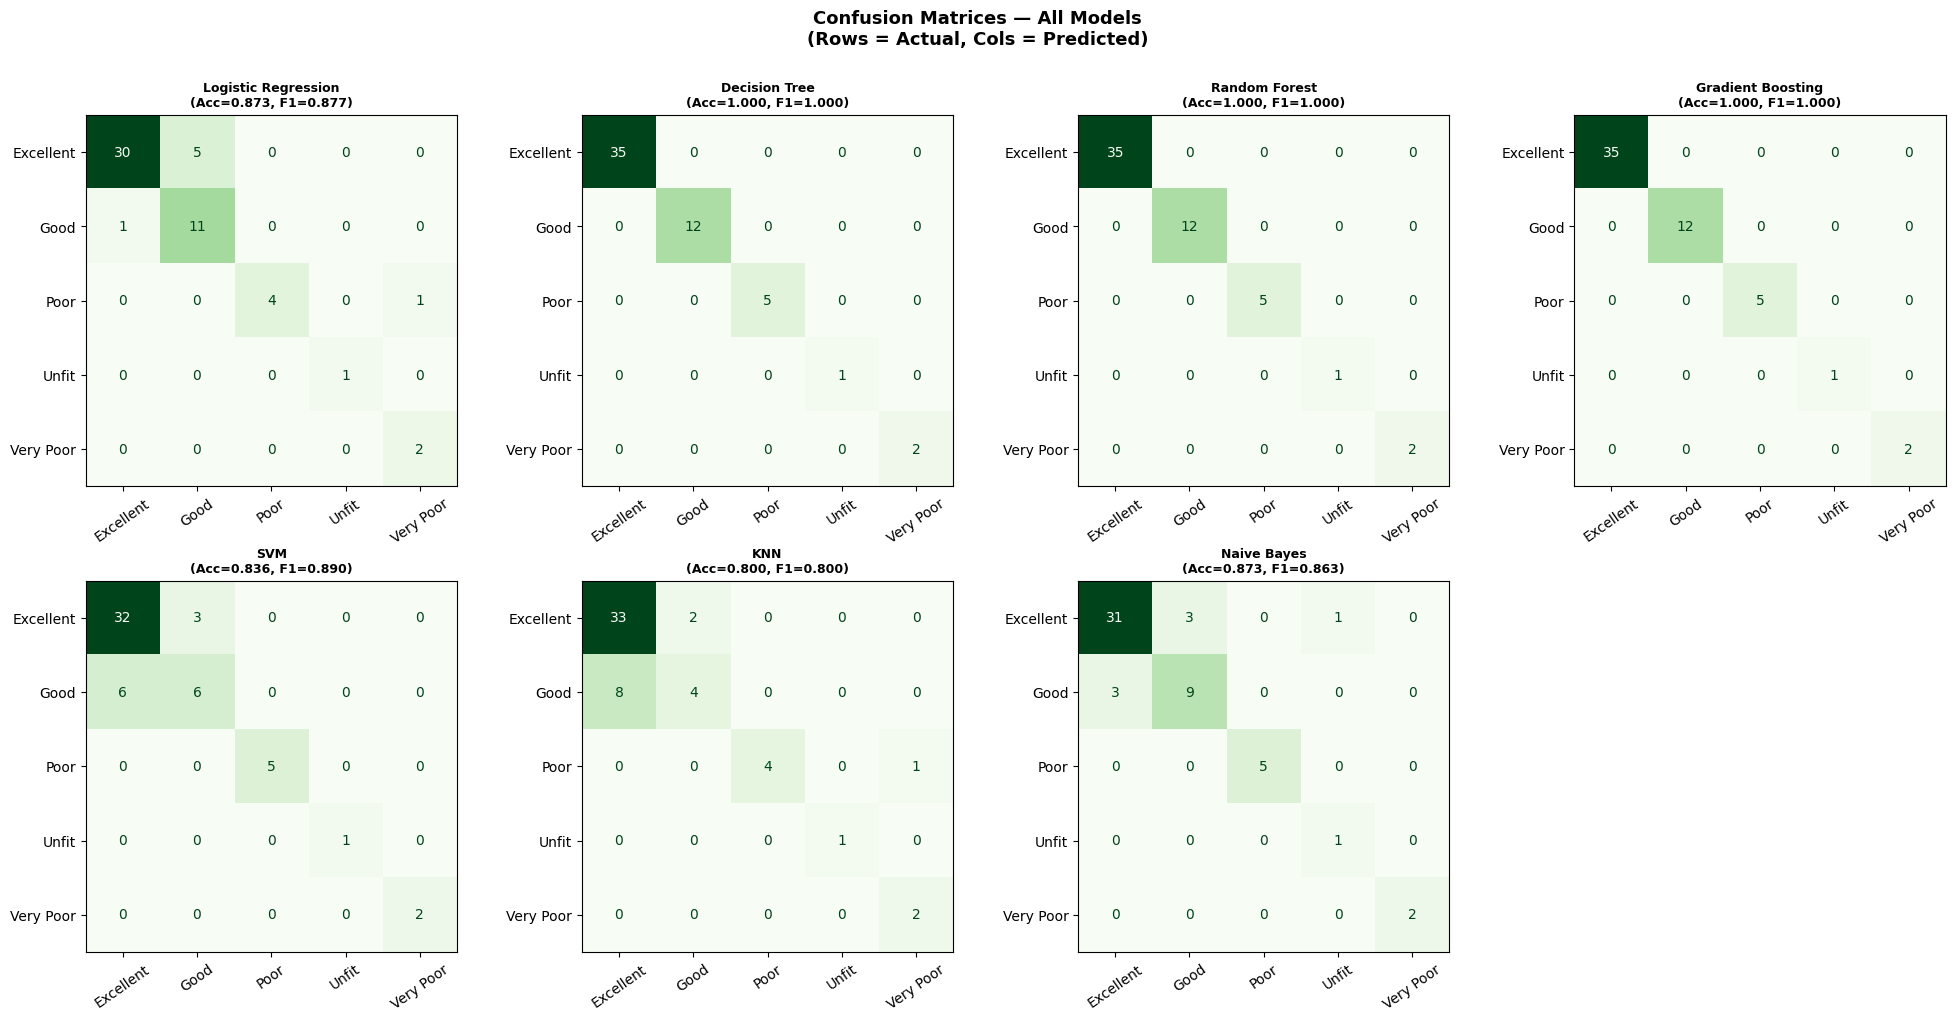

In [417]:
class_labels = [le.inverse_transform([i])[0] for i in sorted(label_map.values())]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False, xticks_rotation=35)
    axes[i].set_title(f'{name}\n(Acc={result["test_acc"]:.3f}, F1={result["f1_macro"]:.3f})',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('')

axes[-1].set_visible(False)  # Hide 8th subplot
plt.suptitle('Confusion Matrices — All Models\n(Rows = Actual, Cols = Predicted)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_10_confusion_matrices.png', bbox_inches='tight', dpi=110)
plt.show()

Detailed Classification Reports 
 - Per-class Precision, Recall, and F1 scores for each model.
 - This reveals which models handle the minority classes best.

In [418]:
for name, result in results.items():
    print('=' * 62)
    print(f'  {name}')
    print('=' * 62)
    print(classification_report(
        y_test, result['y_pred'],
        target_names=class_labels,
        zero_division=0
    ))
    print()

  Logistic Regression
              precision    recall  f1-score   support

   Excellent       0.97      0.86      0.91        35
        Good       0.69      0.92      0.79        12
        Poor       1.00      0.80      0.89         5
       Unfit       1.00      1.00      1.00         1
   Very Poor       0.67      1.00      0.80         2

    accuracy                           0.87        55
   macro avg       0.86      0.91      0.88        55
weighted avg       0.90      0.87      0.88        55


  Decision Tree
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00        35
        Good       1.00      1.00      1.00        12
        Poor       1.00      1.00      1.00         5
       Unfit       1.00      1.00      1.00         1
   Very Poor       1.00      1.00      1.00         2

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00     

In [419]:
# Comprehensive Performance Summary Table 
# Consolidates all metrics into a single sortable table for easy comparison.

summary_rows = []
for name, res in results.items():
    overfit_gap = res['train_acc'] - res['test_acc']  # Train-test gap signals overfitting
    summary_rows.append({
        'Model':        name,
        'Train Acc':    round(res['train_acc'], 4),
        'Test Acc':     round(res['test_acc'],  4),
        'CV Mean':      round(res['cv_mean'],   4),
        'CV Std':       round(res['cv_std'],    4),
        'F1-Macro':     round(res['f1_macro'],  4),
        'Precision-W':  round(precision_score(y_test, res['y_pred'], average='weighted', zero_division=0), 4),
        'Recall-W':     round(recall_score(   y_test, res['y_pred'], average='weighted', zero_division=0), 4),
        'Overfit Gap':  round(overfit_gap,  4),
        'Train Time(s)':round(res['time_seconds'], 2)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('F1-Macro', ascending=False)
summary_df = summary_df.reset_index(drop=True)
summary_df.index += 1  # 1-based ranking

# Save summary table to CSV
summary_df.to_csv('model_performance_summary.csv', index_label='Rank')

print('📊 Model Performance Summary (Sorted by F1-Macro):')
print(summary_df.to_string())

📊 Model Performance Summary (Sorted by F1-Macro):
                 Model  Train Acc  Test Acc  CV Mean  CV Std  F1-Macro  Precision-W  Recall-W  Overfit Gap  Train Time(s)
1        Decision Tree     1.0000    1.0000   0.9909  0.0111    1.0000       1.0000    1.0000       0.0000           0.10
2        Random Forest     1.0000    1.0000   0.9682  0.0232    1.0000       1.0000    1.0000       0.0000           5.66
3    Gradient Boosting     1.0000    1.0000   0.9955  0.0091    1.0000       1.0000    1.0000       0.0000          12.53
4                  SVM     0.9864    0.8364   0.8455  0.0265    0.8896       0.8268    0.8364       0.1500           0.28
5  Logistic Regression     0.9182    0.8727   0.8500  0.0668    0.8767       0.8992    0.8727       0.0455           0.42
6          Naive Bayes     0.8909    0.8727   0.8545  0.0396    0.8630       0.8802    0.8727       0.0182           0.07
7                  KNN     1.0000    0.8000   0.7227  0.0364    0.8004       0.7910    0.8000   

Radar Chart — Top 4 Models 
 - Radar charts visualise multi-metric trade-offs in a compact format.
 - A model 'winning' in all dimensions is ideal but rarely achieved.

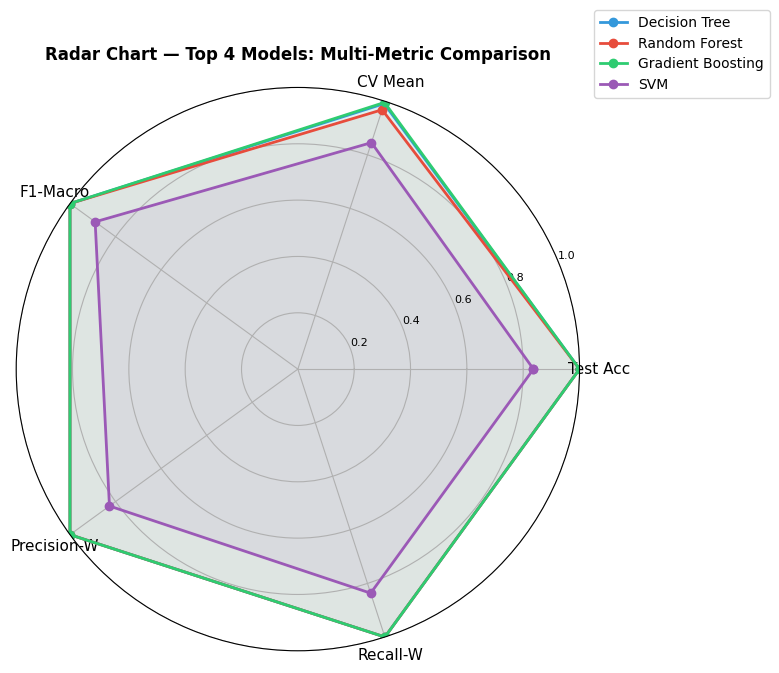

In [420]:
top4 = summary_df.head(4)['Model'].tolist()
metrics = ['Test Acc', 'CV Mean', 'F1-Macro', 'Precision-W', 'Recall-W']
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for model_name, color in zip(top4, colors):
    row = summary_df[summary_df['Model'] == model_name].iloc[0]
    values = [row[m] for m in metrics] + [row[metrics[0]]]
    ax.plot(angles, values, 'o-', linewidth=2.0, color=color, label=model_name)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
ax.set_title('Radar Chart — Top 4 Models: Multi-Metric Comparison',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.savefig('fig_11_radar_chart.png', bbox_inches='tight', dpi=120)
plt.show()

Feature Importance — Random Forest & Gradient Boosting 
 - Tree ensemble models provide built-in feature importance scores.
 - This reveals WHICH water quality parameters drive classification decisions.
 - Actionable insight: High-importance features are the ones operators should monitor most closely and prioritise in treatment processes.

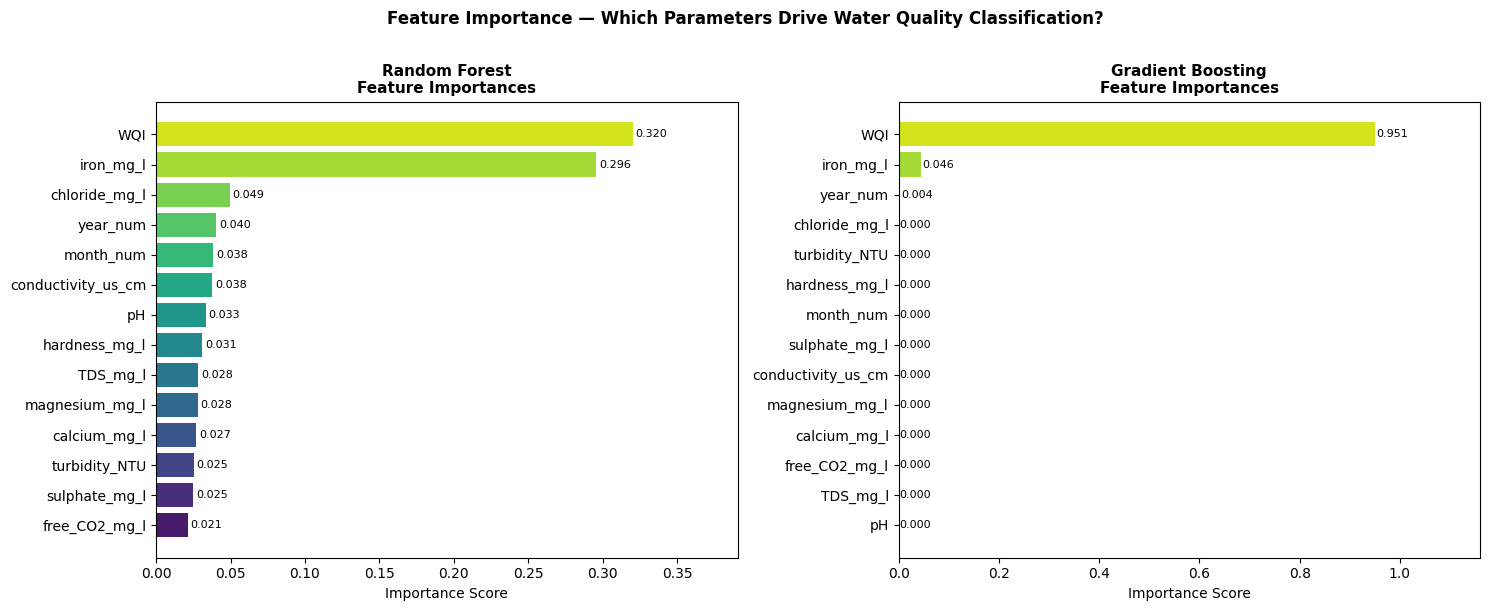


🔍 Top 5 Most Important Features (Random Forest):
WQI              0.320085
iron_mg_l        0.295574
chloride_mg_l    0.049355
year_num         0.040160
month_num        0.038383


In [421]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
importance_models = ['Random Forest', 'Gradient Boosting']

for ax, mname in zip(axes, importance_models):
    importances = results[mname]['model'].feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
    colors_imp = sns.color_palette('viridis', len(feat_imp))
    bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_imp)
    for bar, val in zip(bars, feat_imp.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'{mname}\nFeature Importances', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, feat_imp.max() * 1.22)

plt.suptitle('Feature Importance — Which Parameters Drive Water Quality Classification?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_12_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

# Print top features
print('\n🔍 Top 5 Most Important Features (Random Forest):')
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_, index=FEATURE_COLS)
print(rf_imp.sort_values(ascending=False).head(5).to_string())

---
##  Best Model Selection, Interpretation & Business Impact

**Selection Criteria:**  
The best model is chosen based on:
1. **F1-Macro** — most important for imbalanced multiclass problems (equal weight to all classes)
2. **Cross-validation stability** — low CV std means consistent performance
3. **Overfit gap** — small gap between train and test accuracy
4. **Business priority** — ability to correctly identify `Unfit` and `Very Poor` water (high recall for minority classes)


  🏆 BEST MODEL: Decision Tree
  Test Accuracy      : 1.0000  (100.0%)
  F1-Macro           : 1.0000
  CV Mean Accuracy   : 0.9909 ± 0.0111
  Overfit Gap        : 0.0000

  Detailed Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      1.00      1.00        35
        Good       1.00      1.00      1.00        12
        Poor       1.00      1.00      1.00         5
       Unfit       1.00      1.00      1.00         1
   Very Poor       1.00      1.00      1.00         2

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



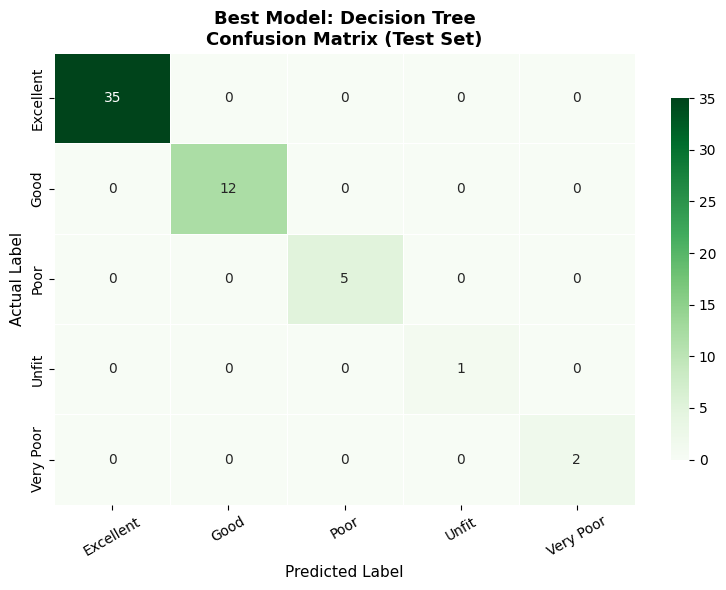

In [422]:
# Select Best Model Based on F1-Macro Score
best_model_name = summary_df.iloc[0]['Model']
best_result     = results[best_model_name]

print('=' * 65)
print(f'  🏆 BEST MODEL: {best_model_name}')
print('=' * 65)
print(f'  Test Accuracy      : {best_result["test_acc"]:.4f}  ({best_result["test_acc"]*100:.1f}%)')
print(f'  F1-Macro           : {best_result["f1_macro"]:.4f}')
print(f'  CV Mean Accuracy   : {best_result["cv_mean"]:.4f} ± {best_result["cv_std"]:.4f}')
print(f'  Overfit Gap        : {best_result["train_acc"] - best_result["test_acc"]:.4f}')

print(f'\n  Detailed Classification Report:')
print(classification_report(
    y_test, best_result['y_pred'],
    target_names=class_labels, zero_division=0
))

# Final confusion matrix — best model
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_title(f'Best Model: {best_model_name}\nConfusion Matrix (Test Set)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_13_best_model_confusion.png', bbox_inches='tight', dpi=120)
plt.show()

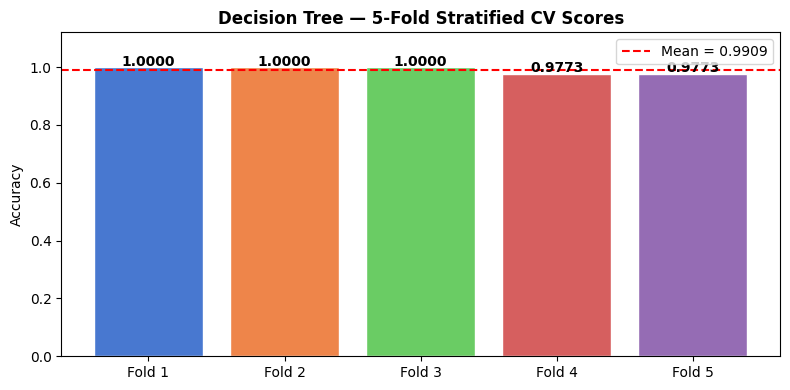


CV Scores : [1.     1.     1.     0.9773 0.9773]
Mean ± Std: 0.9909 ± 0.0111


In [423]:
# Cross-Validation Scores — Best Model 
# Visualise the stability of the best model across 5 folds

cv_scores_best = cross_val_score(
    best_result['model'], X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(folds, cv_scores_best, color=sns.color_palette('muted', 5), edgecolor='white')
for bar, val in zip(bars, cv_scores_best):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
ax.axhline(cv_scores_best.mean(), linestyle='--', color='red', linewidth=1.5,
           label=f'Mean = {cv_scores_best.mean():.4f}')
ax.set_ylim(0, 1.12)
ax.set_title(f'{best_model_name} — 5-Fold Stratified CV Scores',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('fig_14_cv_scores.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nCV Scores : {cv_scores_best.round(4)}')
print(f'Mean ± Std: {cv_scores_best.mean():.4f} ± {cv_scores_best.std():.4f}')

---
## 💼 Business Impact Analysis

### 🎯 Operational Recommendations

| Finding | Business Implication | Recommended Action |
|---------|---------------------|--------------------|
| **WQI is the top predictor** | The composite index captures multi-parameter interactions better than individual parameters alone | Use WQI as the primary real-time monitoring dashboard metric |
| **Turbidity spike in rainy season (Jun–Sep)** | Suspended particles reduce disinfection efficacy; higher cholera risk | Pre-position extra coagulant/flocculant chemicals before June; increase turbidity sampling frequency |
| **pH consistently below WHO ideal (7.0–8.5)** | Acidic water corrodes iron pipes → iron contamination → Unfit classification cascade | Increase lime dosing; implement inline pH correction at distribution points |
| **Iron spikes drive Unfit events** | Iron > 0.3 mg/l causes direct Unfit classification; health risk | Priority-install iron removal filters; investigate pipe network corrosion sources |
| **63.6% of weeks are 'Excellent'** | Kano residents enjoy high-quality water most of the year | Use as positive PR communication; set 'Excellent weeks' as KPI target |
| **Unfit events (only 3 in 10 years)** | Rare but catastrophic; public health emergency when it occurs | Implement automated ML-triggered shut-off/bypass when model predicts Unfit |

### 💰 Financial Impact of ML Deployment

| Scenario | Estimated Annual Impact |
|----------|------------------------|
| Early detection of 1 cholera outbreak prevented | ~₦200M+ in healthcare costs, lost productivity, emergency response |
| Optimised chemical dosing (10% reduction) | ~₦5–15M/year savings in coagulant, chlorine, lime costs |
| Reduced manual lab testing frequency | 2–3 FTE technician hours/week recovered |
| Regulatory penalty avoidance | Avoids potential NAFDAC fines and plant shutdown orders |

### 🚀 Deployment Recommendations

1. **Integrate the best model** into the SCADA/LIMS system for real-time classification
2. **Alert system:** Automate SMS/email alerts to operators when model predicts `Poor`, `Very Poor`, or `Unfit`
3. **Retrain quarterly** with fresh data to capture concept drift (changing water source characteristics)
4. **Monitor feature drift:** If turbidity or iron distributions shift significantly, trigger model retraining
5. **Explainability layer:** Deploy SHAP values alongside predictions so operators understand WHY a classification was made


In [424]:
# Final Consolidated Summary 

print('=' * 70)
print('  TAMBURAWA WTP WATER QUALITY CLASSIFICATION — FINAL SUMMARY')
print('=' * 70)

print('\n📦 DATASET')
print(f'   Samples       : 275 weekly observations (2010–2020)')
print(f'   Features used : {len(FEATURE_COLS)} (11 physicochemical + WQI + 2 temporal)')
print(f'   Target classes: 5 (Excellent, Good, Poor, Very Poor, Unfit)')

print('\n📊 KEY STATISTICAL FINDINGS')
print(f'   Mean pH       : {df["pH"].mean():.2f} (below WHO ideal of 7.0–8.5)')
print(f'   Median WQI    : {df["WQI"].median():.2f} (Excellent = <25)')
print(f'   Max Turbidity : {df["turbidity_NTU"].max():.1f} NTU (WHO limit: 1 NTU)')
print(f'   Iron skewness : {df["iron_mg_l"].skew():.2f} (highly right-skewed — rare but extreme spikes)')

print('\n🤖 MODEL PERFORMANCE RANKING (by F1-Macro):')
print(f'   {summary_df[["Model","Test Acc","F1-Macro","CV Mean","Overfit Gap"]].to_string()}')

print(f'\n🏆 RECOMMENDED MODEL: {best_model_name}')
print(f'   Test Accuracy  : {best_result["test_acc"]:.4f}')
print(f'   F1-Macro       : {best_result["f1_macro"]:.4f}')
print(f'   CV Performance : {best_result["cv_mean"]:.4f} ± {best_result["cv_std"]:.4f}')

  TAMBURAWA WTP WATER QUALITY CLASSIFICATION — FINAL SUMMARY

📦 DATASET
   Samples       : 275 weekly observations (2010–2020)
   Features used : 14 (11 physicochemical + WQI + 2 temporal)
   Target classes: 5 (Excellent, Good, Poor, Very Poor, Unfit)

📊 KEY STATISTICAL FINDINGS
   Mean pH       : 6.63 (below WHO ideal of 7.0–8.5)
   Median WQI    : 20.92 (Excellent = <25)
   Max Turbidity : 9.0 NTU (WHO limit: 1 NTU)
   Iron skewness : 5.06 (highly right-skewed — rare but extreme spikes)

🤖 MODEL PERFORMANCE RANKING (by F1-Macro):
                    Model  Test Acc  F1-Macro  CV Mean  Overfit Gap
1        Decision Tree    1.0000    1.0000   0.9909       0.0000
2        Random Forest    1.0000    1.0000   0.9682       0.0000
3    Gradient Boosting    1.0000    1.0000   0.9955       0.0000
4                  SVM    0.8364    0.8896   0.8455       0.1500
5  Logistic Regression    0.8727    0.8767   0.8500       0.0455
6          Naive Bayes    0.8727    0.8630   0.8545       0.0182
7   